In [1]:
# ── 0. SETUP ──────────────────────────────────────────────────────────────────
import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StringType, IntegerType, FloatType, ArrayType,
    StructType, StructField, LongType, DoubleType
)

spark = SparkSession.builder \
    .appName("MyDigitalTwin-FusionViz") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

# ── Config centrale ────────────────────────────────────────────────────────────
import sys as _sys, os as _os
_sys.path.insert(0, _os.path.abspath(_os.path.join(_os.path.dirname('__file__'), '../../..')))
from config import WAREHOUSE

print(f"Warehouse: {WAREHOUSE}")
assert os.path.exists(WAREHOUSE), f"Warehouse introuvable: {WAREHOUSE}"

def read_table(name):
    return spark.read.parquet(os.path.join(WAREHOUSE, name))

Warehouse: /opt/spark/data/warehouse


26/04/19 00:26:11 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


---
## PARTIE C — Fusion simplifiée → interest_profiles

Content clustering abandonné (clusters TF-IDF trop hétérogènes). On utilise uniquement les **profils comportementaux** comme base des `interest_profiles`.

**Approche** :
1. Charger `data/warehouse/behavioral_clusters` (6 profils déjà écrits)
2. Pour chaque cluster, extraire dynamiquement les top keywords depuis la source dominante (youtube `title`, google `query`, spotify `artistName`, netflix `show_title`, chrome `title`)
3. Écrire `data/warehouse/interest_profiles` avec le schéma attendu par `home.py`

In [2]:
# ── C1. CHARGEMENT DES PROFILS COMPORTEMENTAUX ────────────────────────────────
beh_clusters = read_table("behavioral_clusters")

print("Profils comportementaux :")
beh_clusters.show(truncate=60)

# Dict Python pour usage dans les cellules suivantes
beh_info = {row["cluster_id"]: row.asDict() for row in beh_clusters.collect()}
print(f"\n{len(beh_info)} clusters chargés.")

Profils comportementaux :


+----------+--------------------------------+-----+--------+-----------+-----------+--------+------------------------------------------------------------+----------+
|cluster_id|                           label|emoji|avg_hour|avg_weekday|time_period|day_type|                                               top_platforms|item_count|
+----------+--------------------------------+-----+--------+-----------+-----------+--------+------------------------------------------------------------+----------+
|         0|🌐 Navigation & Social · Journée|   🌐|    15.3|        4.0| Apres-midi| Semaine|[youtube, google, chrome, spotify, tiktok_likes, tiktok_s...|    111512|
|         3|          📱 TikTok · Après-midi|   📱|    14.8|        3.9| Apres-midi| Semaine|                                   [tiktok, instagram_saved]|      2013|
|         0|         📺 YouTube · Après-midi|   📺|    15.7|        3.9| Après-midi| Semaine|                                                   [youtube]|     13821|
|         

In [3]:
# ── C2. EXTRACTION DES KEYWORDS PAR PLATEFORME ────────────────────────────────
from pyspark.ml.feature import Tokenizer, StopWordsRemover, NGram

STOPWORDS_EXTRA = [
    # Français
    "les","des","une","sur","avec","dans","qui","que","par","plus",
    "tout","bien","comme","mais","mon","ton","son","nos","mes",
    "faire","comment","aussi","encore","très",
    # Anglais générique
    "the","and","for","with","you","your","this","that","from",
    "are","was","not","its","but","all","new","best","how",
    # Bruit vidéo/URL
    "https","http","www","com","org","net","html","utm","amp",
    "watch","video","clip","official","officiel","youtube","shorts",
    "16x9","inh","vid","1920x1080","15s","officiel)","(clip",
    "(official","video)","(ft","music","choisissez","chrome",
    # Bruit chrome / email
    "google","gmail","recherche","online","redirect","editor",
    # Bruit Spotify
    "lil","trio","los","del","les","von",
]

STOP_ALL = (StopWordsRemover.loadDefaultStopWords("english")
          + StopWordsRemover.loadDefaultStopWords("french")
          + STOPWORDS_EXTRA)


def extract_top_words(df, text_col, n=15):
    clean = (
        df.filter(F.col(text_col).isNotNull() & (F.length(F.col(text_col)) > 2))
        .withColumnRenamed(text_col, "_text")
        .filter(~F.col("_text").rlike(r'@|^https?://|%[0-9a-fA-F]{2}'))
    )
    tokenized = Tokenizer(inputCol="_text", outputCol="_words").transform(clean)
    filtered  = StopWordsRemover(inputCol="_words", outputCol="_tokens",
                                  stopWords=STOP_ALL).transform(tokenized)
    return (
        filtered.select(F.explode("_tokens").alias("word"))
        .filter(F.length("word") > 2)
        .filter(~F.col("word").rlike(r'^\d'))
        .filter(~F.col("word").rlike(r'[@%#\(\)]'))
        .groupBy("word").count()
        .orderBy(F.desc("count"))
        .limit(n)
        .select("word").rdd.flatMap(lambda x: x).collect()
    )


def extract_bigrams(df, text_col, n=5):
    clean = (
        df.filter(F.col(text_col).isNotNull() & (F.length(F.col(text_col)) > 2))
        .withColumnRenamed(text_col, "_text")
        .filter(~F.col("_text").rlike(r'@|^https?://|%[0-9a-fA-F]{2}'))
    )
    tokenized = Tokenizer(inputCol="_text", outputCol="_words").transform(clean)
    filtered  = StopWordsRemover(inputCol="_words", outputCol="_tokens",
                                  stopWords=STOP_ALL).transform(tokenized)
    bigram_df = NGram(n=2, inputCol="_tokens", outputCol="_ngrams").transform(filtered)
    return (
        bigram_df.select(F.explode("_ngrams").alias("bg"))
        .filter(F.length("bg") > 5)
        .filter(~F.col("bg").rlike(r'[@%#\(\)\d]'))
        .groupBy("bg").count()
        .orderBy(F.desc("count"))
        .limit(n)
        .select("bg").rdd.flatMap(lambda x: x).collect()
    )


def merge_kw(*lists):
    seen, result = set(), []
    for lst in lists:
        for w in lst:
            if w not in seen:
                seen.add(w); result.append(w)
    return result


def safe_read_table(name):
    """Charge une table, retourne None si absente."""
    try:
        return read_table(name).cache()
    except Exception:
        return None


# ── Chargement des sources ─────────────────────────────────────────────────
youtube_df      = read_table("youtube_watch").cache()
google_df       = read_table("google_searches").cache()
chrome_df       = read_table("google_chrome").cache()
spotify_df      = read_table("spotify_streams").cache()
netflix_df      = read_table("netflix_views").cache()
tiktok_s_df     = safe_read_table("tiktok_searches")   # query column
ig_search_df    = safe_read_table("instagram_searches") # query column

# ── Keywords par cluster ───────────────────────────────────────────────────
CLUSTER_KEYWORDS = {
    # 0 : YouTube · Après-midi
    0: merge_kw(
        extract_bigrams(youtube_df, "title"),
        extract_top_words(youtube_df, "title", n=15),
    ),
    # 1 : Soirée connectée — Google soir + Netflix
    1: merge_kw(
        extract_bigrams(netflix_df, "show_title"),
        extract_top_words(netflix_df, "show_title", n=10),
        extract_top_words(google_df.filter(F.col("event_hour") >= 18), "query", n=10),
    ),
    # 2 : TikTok — recherches réelles si dispo, sinon tags manuels
    2: merge_kw(
        extract_bigrams(tiktok_s_df, "query") if tiktok_s_df else [],
        extract_top_words(tiktok_s_df, "query", n=10) if tiktok_s_df else [],
    ) or ["tiktok", "scroll", "shorts", "dance", "viral", "trending", "reels"],
    # 3 : Spotify · Journée
    3: merge_kw(
        extract_top_words(spotify_df, "artistName", n=15),
        extract_bigrams(spotify_df, "artistName"),
    ),
    # 4 : Chrome · Navigation soir
    4: merge_kw(
        extract_bigrams(chrome_df, "title"),
        extract_top_words(chrome_df, "title", n=15),
    ),
    # 5 : Google · Recherches après-midi
    5: merge_kw(
        extract_bigrams(google_df.filter(
            (F.col("event_hour") >= 12) & (F.col("event_hour") < 18)), "query"),
        extract_top_words(google_df.filter(
            (F.col("event_hour") >= 12) & (F.col("event_hour") < 18)), "query", n=15),
    ),
}

# Ajout des recherches Instagram au cluster 5 si disponible
if ig_search_df:
    CLUSTER_KEYWORDS[5] = merge_kw(
        CLUSTER_KEYWORDS[5],
        extract_top_words(ig_search_df, "query", n=10),
    )

print("Keywords extraits par cluster :\n")
for cid, kws in sorted(CLUSTER_KEYWORDS.items()):
    label = beh_info[cid]["label"]
    print(f"  [{cid}] {label}\n       → {kws}\n")


Keywords extraits par cluster :

  [0] 📺 YouTube · Après-midi
       → ['- rediffusion', 'rediffusion squeezie', 'travis scott', 'inazuma eleven', 'eleven -', 'mix', 'live', 'ft.', 'squeezie', 'house', 'one', 'film', 'befr', 'pro', "j'ai", 'travis', 'cards', 'saison', 'rediffusion', 'scott']

  [1] 🎬 Netflix · Soirée
       → ['naruto shippuden', 'x hunter', 'hunter x', 'fairy tail', 'bizarre adventure', 'naruto', 'shippuden', 'hunter', 'fairy', 'tail', 'adventure', 'seven', "jojo's", 'bizarre', 'sins', 'one', 'belgique', 'fifa', 'streaming', 'piece', 'minecraft', 'club', 'font', 'discord', 'film']

  [2] 👻 Activité rare
       → ['freed desire', 'bow bow', 'woops edit', 'x woops', 'desire x', 'edit', 'anyme', 'dance', 'transition', 'song', 'tutorial', 'serato', 'ref', 'original', 'carti']

  [3] 🎵 Spotify · Journée
       → ['damso', 'tiakola', 'ninho', 'zamdane', 'guy2bezbar', 'travis', 'scott', 'mano', 'gazo', 'bad', 'bunny', 'niska', 'gims', 'ziak', 'karol', 'travis scott', 'bad bu

In [4]:
# ── C3. CONSTRUCTION ET ÉCRITURE interest_profiles ────────────────────────────

NOISE_RE = (
    r'(?i)'
    r'\b\d{1,4}x\d{1,4}\b'
    r'|\bINH\b'
    r'|Choisissez Chrome|Kies Chrome|Choose Chrome'
    r'|^Redirect(?:ion)?[\.\s…]*$'
    r'|Ad Blocker'
    r'|VID\s+\d'
    r'|_[A-Z]{2}\b'
    r'|\bBoost_\d'
    r'|LinkedAccounts|FreeBankAccount'
    r'|\b\d+\s*sec\b'
    r'|casino'
    r'|^Shortened[:\s]'
    r'|[\u4e00-\u9fff\u3040-\u30ff]'
    r'|\blening\b|\bkrediet\b'
    r'|CI/CD|TeamCity|JetBrains'
    r'|On the jobsite|leaders aren'
    r'|\bvolvo\b|\bDEWALT\b'
    r'|reconditionné.*Back\s*Mark'
    r'|Enjoy a better'
    r'|^Loading[.\s]*$'
    r'|lust\s+god'
    r'|Recherche\s+Google'
    r'|(\w+)\s+\1\.(com|net|org|be|fr|io)'
)


def extract_samples(df, text_col, n=30):
    return (
        df.filter(F.col(text_col).isNotNull() & (F.length(F.col(text_col)) > 1))
        .filter(~F.col(text_col).rlike(r'@|^https?://|%[0-9a-fA-F]{2}'))
        .filter(~F.col(text_col).rlike(NOISE_RE))
        .filter(~F.col(text_col).rlike(r'^\s*[A-Z0-9_]{5,}\s'))
        .groupBy(text_col).count()
        .orderBy(F.desc("count"))
        .limit(n)
        .select(text_col).rdd.flatMap(lambda x: x).collect()
    )


# Samples par cluster — TikTok enrichi avec les recherches si dispo
CLUSTER_SAMPLES = {
    0: extract_samples(youtube_df, "title"),
    1: extract_samples(netflix_df, "show_title", n=15)
     + extract_samples(google_df.filter(F.col("event_hour") >= 18), "query", n=10),
    2: (extract_samples(tiktok_s_df, "query", n=20) if tiktok_s_df else []),
    3: extract_samples(spotify_df, "artistName"),
    4: extract_samples(chrome_df, "title"),
    5: extract_samples(
           google_df.filter((F.col("event_hour") >= 12) & (F.col("event_hour") < 18)),
           "query"
       ),
}

# Enrichir cluster 5 avec recherches Instagram si disponible
if ig_search_df:
    ig_samples = extract_samples(ig_search_df, "query", n=10)
    CLUSTER_SAMPLES[5] = list(dict.fromkeys(CLUSTER_SAMPLES[5] + ig_samples))[:30]

interest_rows = []
for cid in sorted(beh_info.keys()):
    info = beh_info[cid]
    interest_rows.append((
        cid,
        info["label"],
        info["emoji"],
        CLUSTER_KEYWORDS.get(cid, []),
        info["top_platforms"],
        float(info["avg_hour"]),
        info["time_period"],
        info["day_type"],
        info["item_count"],
        CLUSTER_SAMPLES.get(cid, []),
    ))

schema_ip = StructType([
    StructField("cluster_id",    IntegerType(), False),
    StructField("label",         StringType(),  False),
    StructField("emoji",         StringType(),  True),
    StructField("keywords",      ArrayType(StringType()), True),
    StructField("top_platforms", ArrayType(StringType()), True),
    StructField("avg_hour",      DoubleType(),  True),
    StructField("time_period",   StringType(),  True),
    StructField("day_type",      StringType(),  True),
    StructField("item_count",    LongType(),    True),
    StructField("sample_items",  ArrayType(StringType()), True),
])

interest_profiles_df = spark.createDataFrame(interest_rows, schema_ip)

out_path = os.path.join(WAREHOUSE, "interest_profiles")
interest_profiles_df.write.mode("overwrite").parquet(out_path)

print(f"Ecrit dans : {out_path}\n")
interest_profiles_df.select("cluster_id", "label", "sample_items", "item_count").show(truncate=70)


Ecrit dans : /opt/spark/data/warehouse/interest_profiles

+----------+-----------------------+----------------------------------------------------------------------+----------+
|cluster_id|                  label|                                                          sample_items|item_count|
+----------+-----------------------+----------------------------------------------------------------------+----------+
|         0|📺 YouTube · Après-midi|[Gazo - Guinea Man [Mixtape], Damso - Jean Reno, DJ ZAYON - SALEGY ...|     13821|
|         1|    🎬 Netflix · Soirée|[Naruto Shippuden, Naruto, Hunter X Hunter (2011), Fairy Tail, JoJo...|      4288|
|         2|       👻 Activité rare|[anyme023, PGE, playboicarti, anyme bb jacque, freed from desire x ...|         1|
|         3|   🎵 Spotify · Journée|[Damso, Tiakola, Ninho, Zamdane, Guy2Bezbar, Travis Scott, La Mano ...|     33972|
|         4|   💻 Navigation · Soir|[Photopea | Online Photo Editor, AliExpress - Online winkelen voor ...|       

---
## PARTIE D — Visualisation des profils comportementaux

PCA sur TF-IDF abandonnée (content clustering retiré). On visualise à la place :
- **Bar chart** : volume d'activité par profil
- **Scatter heure** : heure moyenne d'activité par profil (taille ∝ volume)

In [5]:
# ── D0. DÉPENDANCES VISUALISATION ─────────────────────────────────────────────
%pip install --quiet matplotlib numpy


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/tmp/ipykernel_10990/3067066147.py:41: UserWarning: Glyph 128250 (\N{TELEVISION}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10990/3067066147.py:41: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10990/3067066147.py:41: UserWarning: Glyph 128123 (\N{GHOST}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10990/3067066147.py:41: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10990/3067066147.py:41: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10990/3067066147.py:41: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10990/3067066147.py:46: UserWarning: Glyph 128250 (\N{TELEVISION}) missing from font(s) DejaVu Sans.
  plt.savefig(out_img, dpi=120, bbo

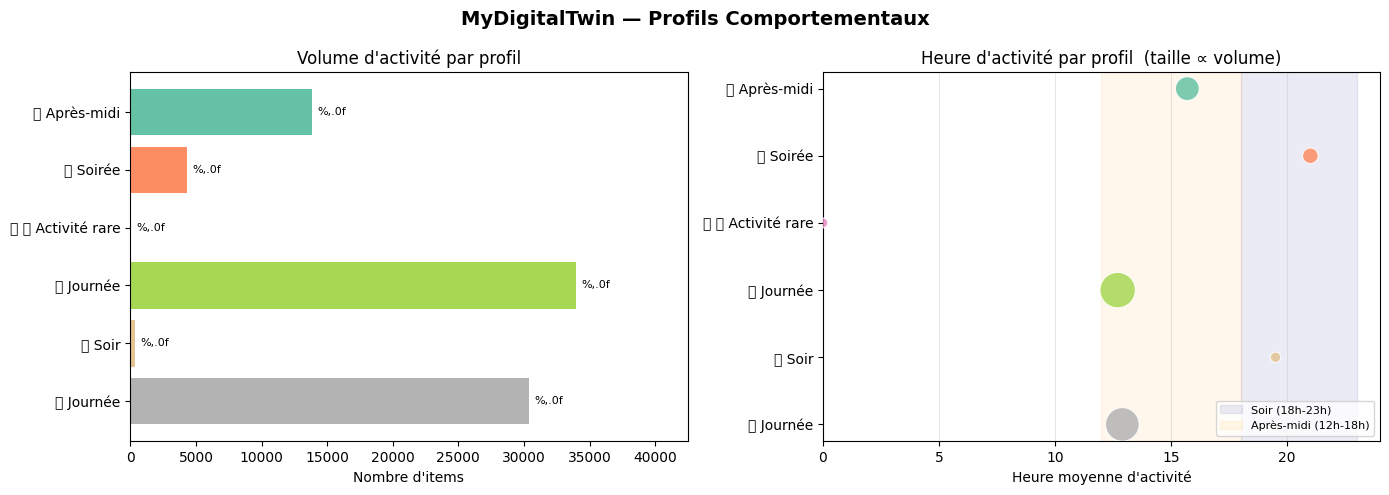

Visualisation sauvegardée : C:/Users/arnau/Documents/MyDigitalTwin/app/assets/behavioral_profiles.png


In [6]:
# ── D1. VISUALISATION — PROFILS COMPORTEMENTAUX ───────────────────────────────
try:
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import numpy as np

    pdf = interest_profiles_df.toPandas()
    pdf = pdf.sort_values("cluster_id").reset_index(drop=True)

    short_labels = [f"{row['emoji']} {row['label'].split('·')[-1].strip()}"
                    for _, row in pdf.iterrows()]
    colors = cm.Set2(np.linspace(0, 1, len(pdf)))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- Graphique 1 : Items par cluster ---
    bars = ax1.barh(short_labels, pdf["item_count"], color=colors)
    ax1.set_xlabel("Nombre d'items")
    ax1.set_title("Volume d'activité par profil")
    ax1.bar_label(bars, fmt='%,.0f', padding=4, fontsize=8)
    ax1.set_xlim(0, pdf["item_count"].max() * 1.25)
    ax1.invert_yaxis()

    # --- Graphique 2 : Heure moyenne d'activité ---
    sizes = (pdf["item_count"] / pdf["item_count"].max() * 600 + 50).values
    ax2.scatter(pdf["avg_hour"], range(len(pdf)),
                s=sizes, c=range(len(pdf)), cmap="Set2",
                alpha=0.85, zorder=3, edgecolors="white", linewidths=0.8)
    ax2.set_yticks(range(len(pdf)))
    ax2.set_yticklabels(short_labels)
    ax2.set_xlabel("Heure moyenne d'activité")
    ax2.set_title("Heure d'activité par profil  (taille ∝ volume)")
    ax2.axvspan(18, 23, alpha=0.08, color="navy",   label="Soir (18h-23h)")
    ax2.axvspan(12, 18, alpha=0.08, color="orange", label="Après-midi (12h-18h)")
    ax2.set_xlim(0, 24)
    ax2.legend(loc="lower right", fontsize=8)
    ax2.grid(axis="x", alpha=0.3)
    ax2.invert_yaxis()

    plt.suptitle("MyDigitalTwin — Profils Comportementaux", fontsize=14, fontweight="bold")
    plt.tight_layout()

    ASSETS = "C:/Users/arnau/Documents/MyDigitalTwin/app/assets"
    os.makedirs(ASSETS, exist_ok=True)
    out_img = os.path.join(ASSETS, "behavioral_profiles.png")
    plt.savefig(out_img, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Visualisation sauvegardée : {out_img}")

except ImportError:
    print("matplotlib non disponible — skipping visualization")

In [7]:
spark.stop()
print("Spark session fermée. Notebook terminé.")

Spark session fermée. Notebook terminé.
